In [2]:
import geopandas as gpd
import numpy as np
from mgwr.gwr import GWR
from mgwr.sel_bw import Sel_BW
from mgwr.utils import shift_colormap
from libpysal.weights import KNN
from sklearn.preprocessing import StandardScaler
from models.gpkg import GeoPackage

In [81]:
gpkg = GeoPackage()
gdf = gpkg.read_layer('vindex_1985_2023_good')
se = gpkg.read_layer('sistemas_ecologicos_RS_hasenack')

In [153]:
biomas = gpkg.read_layer('biomas_rs_faixa_trans_final')

In [154]:
biomas['area_km²'] = biomas.geometry.area / 1e6

In [157]:
biomas['area_perc'] = round((biomas['area_km²'] / biomas['area_km²'].sum()) * 100, 2)

In [ ]:
biomas[['bioma', 'area_km²', 'area_perc']]

,area_km²,bioma
0,166506.267202,Pampa
1,64494.330250,Mata atlântica
2,50814.610762,Faixa de transição


In [ ]:
from tools.exposure import spatial_join_pampa
test = gdf.copy()
test = spatial_join_pampa(gdf, se, bioma_col='SISTEMA')
test.head()

In [83]:
test

,pol_id,nome_ti,etnia_nome,regeneration_%_se,degeneration_%_se,forest_cover_2023_%_se,bioma,forest_formation_se,grassland_se,soybean_se,...,uhe_density_ex,heat_density_se,heat_density_ex,ex_score,se_score,ca_score,vulnerability_raw,vulnerability_index,geometry,SISTEMA
0,0,0,0,65.798611,0.087977,44.041071,Faixa de transição,0.898729,0.000000,0.000000,...,0.0,0.000000,0.030998,0.163542,0.045769,0.489776,0.379387,0.207535,MULTIPOLYGON Z (((5366397.945 6711242.732 -9.4...,Outras formacoes
1,1,Arakuã - Ka'aguy Mirim,Guarani,58.593750,0.016561,48.376481,Pampa,0.552550,0.486335,0.002557,...,0.0,0.000000,0.087810,0.150071,0.033952,0.517837,0.344744,0.153594,MULTIPOLYGON Z (((5287377.789 6653737.619 -9.4...,Campo misto de andropogoneas e compostas
2,2,Gãh Ré,Kaingang,24.242424,0.007519,67.241379,Pampa,0.441847,0.289992,0.000000,...,0.0,0.000000,0.093504,0.186935,0.020084,0.306585,0.438157,0.299044,MULTIPOLYGON Z (((5276505.692 6670909.123 -9.4...,Campo misto de andropogoneas e compostas
3,3,0,0,24.855491,0.187500,14.124668,Pampa,0.000000,0.054832,0.000000,...,0.0,0.000000,0.131404,0.104420,0.028440,0.194844,0.401245,0.241570,MULTIPOLYGON Z (((5259479.817 6647130.844 -9.4...,Campo misto de andropogoneas e compostas
4,4,0,0,0.000000,0.174178,37.624861,Faixa de transição,0.852439,0.000000,0.000000,...,0.0,0.000000,0.000000,0.083554,0.046385,0.498697,0.297040,0.079316,MULTIPOLYGON Z (((5372998.368 6713607.226 -9.4...,Outras formacoes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
136,133,0,0,0.000000,0.000000,0.000000,Mata atlântica,0.000000,0.000000,0.000000,...,0.0,0.000000,0.011303,0.352547,0.117541,0.172300,0.745988,0.696032,MULTIPOLYGON Z (((5310787.763 6714792.233 -9.4...,Outras formacoes
137,135,0,0,10.400000,0.000000,18.421053,Mata atlântica,0.492478,0.000000,0.000000,...,0.0,0.000000,0.058172,0.356240,0.067149,0.246059,0.674702,0.567549,MULTIPOLYGON Z (((5204224.535 6727070.187 -9.4...,Outras formacoes
138,137,0,0,8.695652,0.617925,18.693694,Mata atlântica,0.355507,0.000000,0.000000,...,0.0,0.000000,0.064373,0.279042,0.184587,0.341081,0.683269,0.582989,MULTIPOLYGON Z (((5237923.486 6735323.035 -9.4...,Outras formacoes
139,138,0,0,9.713024,0.142594,38.143004,Mata atlântica,0.606368,0.000000,0.040307,...,0.0,0.000000,0.007349,0.068557,0.100872,0.428859,0.359810,0.000000,MULTIPOLYGON Z (((5277007.845 6797554.234 -9.4...,Outras formacoes


In [140]:
# Calcular centroides das TIs (necessário para coordenadas)
gdf = test.copy()
gdf["centroid"] = gdf.geometry.centroid
coords = np.array(list(zip(gdf.centroid.x, gdf.centroid.y)))

cols = ["urban_area_ex"]

# Definir variáveis
y = gdf["vulnerability_index"].values.reshape((-1,1))  # variável dependente
X = gdf[cols].values

# # Normalizar X (boa prática para GWR)
# scaler = StandardScaler()
# X = scaler.fit_transform(X)


In [141]:
bw = Sel_BW(coords, y, X).search()
print("Bandwidth ótimo:", bw)


Bandwidth ótimo: 45.0


In [142]:
gwr_model = GWR(coords, y, X, bw)
gwr_results = gwr_model.fit()

print(gwr_results.summary())


Model type                                                         Gaussian
Number of observations:                                                 141
Number of covariates:                                                     2

Global Regression Results
---------------------------------------------------------------------------
Residual sum of squares:                                              6.659
Log-likelihood:                                                      15.154
AIC:                                                                -26.309
AICc:                                                               -24.133
BIC:                                                               -681.219
R2:                                                                   0.082
Adj. R2:                                                              0.076

Variable                              Est.         SE  t(Est/SE)    p-value
------------------------------- ---------- ---------- ------

In [143]:
# Coeficientes para cada variável
for i, var in enumerate(cols):
    gdf[f"coef_{var}"] = gwr_results.params[:, i]

# R² local
gdf["R2_local"] = gwr_results.localR2


In [144]:
gdf['coef_urban_area_ex']

0      0.243290
1      0.270647
2      0.296983
3      0.297119
4      0.247901
         ...   
136    0.272616
137    0.584309
138    0.562413
139    0.344541
140    0.299640
Name: coef_urban_area_ex, Length: 141, dtype: float64

In [145]:
gdf.groupby("SISTEMA")[[f"coef_{v}" for v in cols]].mean()

,coef_urban_area_ex
SISTEMA,
Campo arbustivo,0.452975
Campo com barba-de-bode,0.529121
Campo graminoso,0.437775
Campo litoraneo,0.283434
Campo misto de andropogoneas e compostas,0.357640
Floresta Estacional,0.324901
Outras formacoes,0.439182


In [146]:
gdf.groupby(['SISTEMA']).size()

SISTEMA
Campo arbustivo                              3
Campo com barba-de-bode                      6
Campo graminoso                              2
Campo litoraneo                             17
Campo misto de andropogoneas e compostas    32
Floresta Estacional                          9
Outras formacoes                            72
dtype: int64

In [147]:
gdf['urban_area_ex'].loc[gdf['SISTEMA'] != 'Campo com barba-de-bode'].describe()

count    135.000000
mean       0.130579
std        0.225941
min        0.000000
25%        0.003072
50%        0.014680
75%        0.139182
max        1.000000
Name: urban_area_ex, dtype: float64

In [138]:
gdf['coef_soybean_ex'].describe()

count    141.000000
mean       0.378230
std        0.075002
min        0.287734
25%        0.314782
50%        0.352607
75%        0.434366
max        0.551928
Name: coef_soybean_ex, dtype: float64

In [151]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_scatter_gwr(data: gpd.GeoDataFrame, x: str, y: str, hue: str, region: str):# Scatter plot de soja vs vulnerabilidade, colorido pelo coeficiente GWR
    plt.figure(figsize=(12, 6))
    legend_dict = {
        "soybean": "Soja",
        "urban_area": "Áreas urbanas",
        "forest_plantation": "Silvicultura",
        "agropec": "Agropecuária",
        "mining": "Mineração",
        "roads": "Estradas",
        "heat": "Incêndios"
    }
    y_column = {
        "vulnerability_index": "Índice de Vulnerabilidade",
        "ca_score": "Capacidade Adaptativa",
        "ex_score": "Exposição",
        "se_score": "Sensibilidade"
    }
    for k, v in legend_dict.items():
        if k in x:
            x_leg = v
    if "ex" in x:
        x_leg = x_leg + " (exposição)"
    else:
        x_leg = x_leg + " (sensibilidade)"
    sns.scatterplot(
        data=data,
        x=x,
        y=y,
        hue=hue,  # coeficiente local
        style=region,         # diferentes símbolos por sistema
        palette='coolwarm',
        s=100
    )

    plt.xlabel(x_leg)
    plt.ylabel(y_column.get(y, 0))
    plt.title('Relação entre áreas urbanas e Vulnerabilidade por Sistema (colorido pelo coeficiente GWR)')
    # plt.colorbar()  # legenda da cor
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()


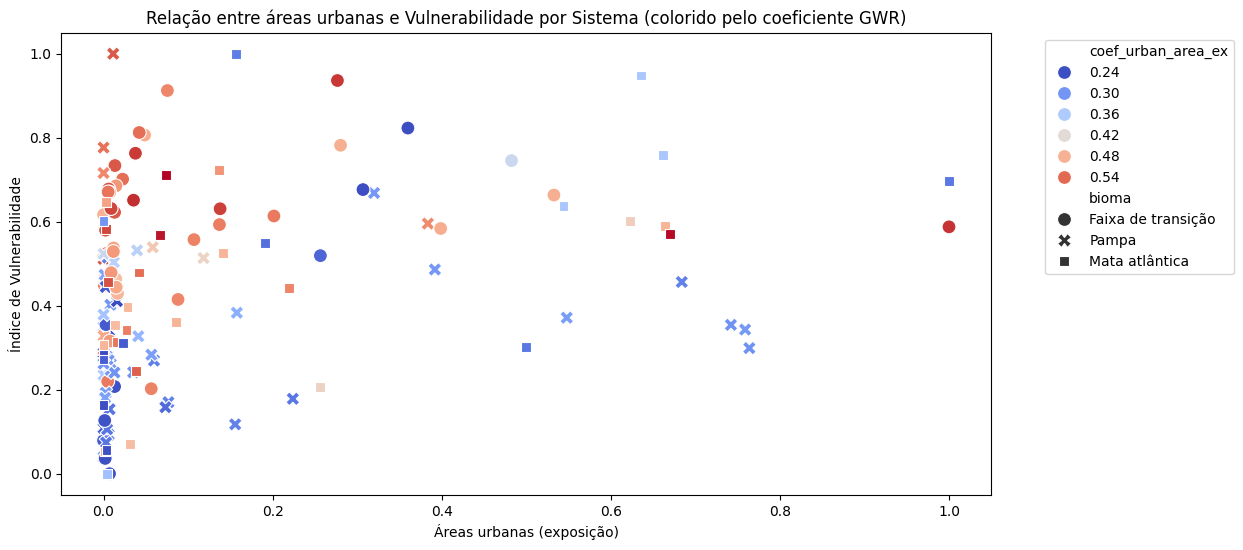

In [152]:
plot_scatter_gwr(gdf, 'urban_area_ex', 'vulnerability_index', 'coef_urban_area_ex', 'bioma')